In [1]:
# Step 0: Mount

import os
import shutil
from google.colab import drive

mount_point = '/content/drive'

print("1. Force Unmounting...")
try:
    drive.flush_and_unmount()
    print("Unmounted successfully.")
except Exception:
    print("Drive was not mounted (safe to proceed).")

print("2. Cleaning stale directory...")
if os.path.exists(mount_point):
    # Ensure it is not a mount point before deleting
    if os.path.ismount(mount_point):
        print(f"   CRITICAL STOP: {mount_point} is still mounted! Do not delete.")
    else:
        # Delete the local folder so we can remount cleanly
        try:
            shutil.rmtree(mount_point)
            print(f"Deleted stale folder: {mount_point}")
        except OSError as e:
            print(f"Error deleting folder: {e}")
else:
    print("No stale folder found.")

print("3. Remounting fresh...")
drive.mount(mount_point, force_remount=True)

1. Force Unmounting...
Drive not mounted, so nothing to flush and unmount.
Unmounted successfully.
2. Cleaning stale directory...
No stale folder found.
3. Remounting fresh...
Mounted at /content/drive


In [6]:
# Step 1.1: Setup
# Initializes libraries, API keys, and creates directory structure

import os
import pandas as pd
import numpy as np
import requests
import json
import time
import shutil
from datetime import datetime, timedelta
from tqdm import tqdm
import glob
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.lines import Line2D

API_KEY = "69264caef0e1d6.09361600"  # Your EODHD Key
# EODHD data quality degrades significantly pre-2017, giving the model 8 full years to work with
START_DATE = "2017-01-01"
END_DATE = "2025-12-31"

BASE_DIR = "/content/drive/MyDrive/VOO_Replica_01.30.2026"

# Subfolders
DIRS = {
    "constituents": os.path.join(BASE_DIR, "data/constituents"),
    "fundamentals": os.path.join(BASE_DIR, "data/fundamentals"),
    "prices":       os.path.join(BASE_DIR, "data/prices"),
    "output":       os.path.join(BASE_DIR, "output"),
    "artifacts":    os.path.join(BASE_DIR, "artifacts"),
}

# Create directories
print(f"Basing project at: {BASE_DIR}")
for key, path in DIRS.items():
    if not os.path.exists(path):
        os.makedirs(path)
        print(f"  Created: {path}")
    else:
        print(f"  Found: {path}")

Basing project at: /content/drive/MyDrive/VOO_Replica_01.30.2026
  Found: /content/drive/MyDrive/VOO_Replica_01.30.2026/data/constituents
  Found: /content/drive/MyDrive/VOO_Replica_01.30.2026/data/fundamentals
  Found: /content/drive/MyDrive/VOO_Replica_01.30.2026/data/prices
  Found: /content/drive/MyDrive/VOO_Replica_01.30.2026/output
  Found: /content/drive/MyDrive/VOO_Replica_01.30.2026/artifacts


In [ ]:
#Step 2.1: Constituent Generation

# Downloads the historical S&P 500 constituent list from GitHub
# Expands constituents into a daily map of active tickers for the target window

print(">>> [Step 2] Generating constituents...")

# 1. Download master list (GitHub)
GITHUB_URL = "https://raw.githubusercontent.com/fja05680/sp500/refs/heads/master/S%26P%20500%20Historical%20Components%20%26%20Changes(01-17-2026).csv"
UNIV_PATH = os.path.join(DIRS["constituents"], "sp500_daily_map.parquet")

try:
    print("    Downloading constituents from GitHub...")
    # CSV reading
    df_git = pd.read_csv(GITHUB_URL)

    # Clean column names
    df_git.columns = [c.lower() for c in df_git.columns]

    df_git['date'] = pd.to_datetime(df_git['date'])
    df_git = df_git.sort_values('date')

    # 2. Filter for time window
    # Start earlier to ensure Jan 1st is populated
    mask = (df_git['date'] >= "2016-12-01") & (df_git['date'] <= END_DATE)

    # 3. Expand to daily map
    print("    Expanding to daily trading map...")
    all_days = pd.date_range(start=START_DATE, end=END_DATE, freq='D')

    # Reindex to daily (forward fill state)
    df_git.set_index('date', inplace=True)
    daily_map = df_git.reindex(all_days, method='ffill').reset_index()
    daily_map.rename(columns={'index': 'date'}, inplace=True)

    # 4. Explode tickers
    print("    Parsing ticker lists...")
    daily_map['symbol'] = daily_map['tickers'].str.split(',')
    constituents = daily_map.explode('symbol')[['date', 'symbol']].dropna()

    # 5. Normalize symbols
    constituents['symbol'] = constituents['symbol'].str.strip().str.replace('.', '-', regex=False)

    # Save
    constituents.to_parquet(UNIV_PATH, index=False)

    # Validation
    unique_count = constituents['symbol'].nunique()
    jan_17_count = constituents[constituents['date'] == '2017-01-03']['symbol'].nunique()

    print(f"Saved daily map to: {UNIV_PATH}")
    print(f"Total unique tickers: {unique_count}")
    print(f"Active tickers on Jan 2017: {jan_17_count} (Target: ~500)")
    print("Constituents generation complete.")

except Exception as e:
    print(f"Error: {e}")

>>> [Step 2] Generating constituents...
    Expanding to daily trading map...
    Parsing ticker lists...
Saved daily map to: /content/drive/MyDrive/VOO_Replica_01.30.2026/data/constituents/sp500_daily_map.parquet
Total unique tickers: 702
Active tickers on Jan 2017: 506 (Target: ~500)
Constituents generation complete.


In [ ]:
# Step 2.2: Constituents Patching

# Creates constituent parquet
# Maps historical tickers (FB) -> current tickers (META) so the engine finds data

print(">>> [Step 2.2] Patching constituents")

# 1. Load raw constituents
raw_path = os.path.join(DIRS["constituents"], "sp500_daily_map.parquet")
if not os.path.exists(raw_path):
    print("Raw constituents not found. Run Step 2.1 first.")
else:
    df_univ = pd.read_parquet(raw_path)

    # 2. Define fixes
    TICKER_FIXES = {
        'FB': 'META', 'RE': 'EG', 'CDAY': 'DAY', 'ANTM': 'ELV', 'STJ': 'ABT',
        'WLTW': 'WTW', 'CERN': 'ORCL', 'XL': 'AXP', 'INFO': 'SPGI',
        'DISCA': 'WBD', 'DISCK': 'WBD', 'VIAB': 'PARA', 'BRK.B': 'BRK-B', 'BF.B': 'BF-B',
        'LLTC': 'ADI', 'CVC': 'ALT', 'LVLT': 'CTL', 'DOW': 'DOW',
        'LB': 'BBWI', 'HCP': 'DOC', 'WYND': 'TNL', 'STI': 'TFC', 'FOX': 'FOX', 'FOXA': 'FOXA'
    }

    # 3. Apply map
    # If ticker is in dictionary, replace it. Else keep original.
    df_univ['symbol'] = df_univ['symbol'].replace(TICKER_FIXES)

    # 4. Save map
    clean_path = os.path.join(DIRS["constituents"], "sp500_daily_map_clean.parquet")
    df_univ.to_parquet(clean_path)

    print(f"Saved clean constituents to: {clean_path}")
    print(f"Rows: {len(df_univ)}")

>>> [Step 2.2] Patching constituents
Saved clean constituents to: /content/drive/MyDrive/VOO_Replica_01.30.2026/data/constituents/sp500_daily_map_clean.parquet
Rows: 1657871


In [ ]:
# Step 3.1: Price Ingestion

# Downloads daily price data from EODHD
# Creates constituent price parquets

print(">>> [Step 3.1] Ingesting Daily Prices (EODHD)...")

# Maps historical ticker -> Current EODHD ticker
TICKER_MAP = {
    # Standard fixes
    'FB': 'META', 'RE': 'EG', 'CDAY': 'DAY', 'ANTM': 'ELV', 'STJ': 'ABT',
    'WLTW': 'WTW', 'CERN': 'ORCL', 'XL': 'AXP', 'INFO': 'SPGI',
    'DISCA': 'WBD', 'DISCK': 'WBD', 'VIAB': 'PARA', 'BRK.B': 'BRK-B', 'BF.B': 'BF-B',
    'LLTC': 'ADI', 'CVC': 'ALT', 'LVLT': 'CTL', 'DOW': 'DOW',

    # Renamed companies
    'LB': 'BBWI',   # L Brands -> Bath & Body Works
    'HCP': 'DOC',   # HCP -> Healthpeak (DOC)
    'PEAK': 'DOC',  # Healthpeak -> DOC
    'WYND': 'TNL',  # Wyndham -> Travel + Leisure
    'TNL': 'WYN',   # Travel + Leisure (Historical ticker WYN)
    'STI': 'TFC',   # SunTrust -> Truist
    'FOXA': 'FOXA',

    # 1:1 Mergers
    'PX': 'LIN',    # Praxair -> Linde (1:1 Ratio)
    'SCG': 'D',     # SCANA -> Dominion (Proxy)
    'CA': 'AVGO',   # CA -> Broadcom (Proxy)

    # Excluded
    # 'LLL': 'LHX' -> Ratio is 1.30, mapping creates 30% pricing error.
}

# Targets
univ_path = os.path.join(DIRS["constituents"], "sp500_daily_map_clean.parquet")
if not os.path.exists(univ_path):
    univ_path = os.path.join(DIRS["constituents"], "sp500_daily_map.parquet")

univ = pd.read_parquet(univ_path)
all_tickers = sorted(univ['symbol'].unique())
print(f"Targeting {len(all_tickers)} unique tickers.")

# Download
missing = []
for original_ticker in tqdm(all_tickers, desc="Downloading prices"):
    save_path = os.path.join(DIRS["prices"], f"{original_ticker}.parquet")

    # Skip if exists
    if os.path.exists(save_path): continue

    # Map to current ticker
    api_ticker = TICKER_MAP.get(original_ticker, original_ticker)

    success = False
    # Variations
    variations = [api_ticker, api_ticker.replace("-", "."), api_ticker.replace(".", "-")]

    for v in variations:
        if success: break
        try:
            url = f"https://eodhd.com/api/eod/{v}.US?from={START_DATE}&to={END_DATE}&api_token={API_KEY}&fmt=json"
            r = requests.get(url, timeout=5)
            if r.status_code == 200:
                data = r.json()
                if isinstance(data, list) and len(data) > 10:
                    df = pd.DataFrame(data)
                    df['date'] = pd.to_datetime(df['date'])
                    # Clean & save
                    df = df[['date', 'adjusted_close', 'close', 'volume']].set_index('date')
                    df.to_parquet(save_path)
                    success = True
        except: pass
        time.sleep(0.05)

    if not success:
        missing.append(original_ticker)

print(f"Price ingestion complete. Missing: {len(missing)}")
if missing:
    print(f"Failed tickers: {missing[:10]}...")

>>> [Step 3.1] Ingesting Daily Prices (EODHD)...
Targeting 685 unique tickers.


Price ingestion complete. Missing: 0


In [ ]:
# Step 3.2: Fundamentals Ingestion

# Downloads historical share counts from EODHD
# Creates share counts parquets

print(">>> Ingesting fundamentals")

# Load ticker list
univ_path = os.path.join(DIRS["constituents"], "sp500_daily_map_clean.parquet")
if not os.path.exists(univ_path):
    univ_path = os.path.join(DIRS["constituents"], "sp500_daily_map.parquet")

univ = pd.read_parquet(univ_path)
all_tickers = sorted(univ['symbol'].unique())

# Maps historical ticker -> Current EODHD ticker
TICKER_MAP = {
    # Standard Fixes
    'FB': 'META', 'RE': 'EG', 'CDAY': 'DAY', 'ANTM': 'ELV', 'STJ': 'ABT',
    'WLTW': 'WTW', 'CERN': 'ORCL', 'XL': 'AXP', 'INFO': 'SPGI',
    'DISCA': 'WBD', 'DISCK': 'WBD', 'VIAB': 'PARA', 'BRK.B': 'BRK-B', 'BF.B': 'BF-B',
    'LLTC': 'ADI', 'CVC': 'ALT', 'LVLT': 'CTL', 'DOW': 'DOW',

    # Renamed companies
    'LB': 'BBWI',   # L Brands -> Bath & Body Works
    'HCP': 'DOC',   # HCP -> Healthpeak (DOC)
    'PEAK': 'DOC',  # Healthpeak -> DOC
    'WYND': 'TNL',  # Wyndham -> Travel + Leisure
    'TNL': 'WYN',   # Travel + Leisure (Historical ticker WYN)
    'STI': 'TFC',   # SunTrust -> Truist
    'FOX': 'FOX',
    'FOXA': 'FOXA',

    # 1:1 Mergers
    'PX': 'LIN',    # Praxair -> Linde (1:1 Ratio)
    'SCG': 'D',     # SCANA -> Dominion (Proxy)
    'CA': 'AVGO',   # CA -> Broadcom (Proxy)

    # Excluded
    # 'LLL': 'LHX' -> Ratio is 1.30, mapping creates 30% pricing error.
}

shares_data = []
missing_funds = []

# Download
for original_ticker in tqdm(all_tickers, desc="Fetching fundamentals"):
    # Map to current ticker
    api_ticker = TICKER_MAP.get(original_ticker, original_ticker)

    # EODHD fundamentals URL
    url = f"https://eodhd.com/api/fundamentals/{api_ticker}.US?api_token={API_KEY}&fmt=json"

    try:
        r = requests.get(url, timeout=5)
        if r.status_code == 200:
            data = r.json()
            # Navigate JSON
            financials = data.get('Financials', {}).get('Balance_Sheet', {}).get('quarterly', {})

            if financials:
                found_shares = False
                for date_str, metrics in financials.items():
                    shares = metrics.get('commonStockSharesOutstanding')
                    if shares:
                        try:
                            shares_val = float(shares)
                            if shares_val > 0:
                                shares_data.append({
                                    'date': pd.to_datetime(date_str),
                                    'symbol': original_ticker,
                                    'shares': shares_val
                                })
                                found_shares = True
                        except: pass
                if not found_shares:
                    missing_funds.append(original_ticker)
            else:
                missing_funds.append(original_ticker)
        else:
            missing_funds.append(original_ticker)
    except:
        missing_funds.append(original_ticker)

    time.sleep(0.05)

# Save
if shares_data:
    df_shares = pd.DataFrame(shares_data)
    df_shares = df_shares.sort_values(['symbol', 'date'])

    save_path = os.path.join(DIRS["fundamentals"], "shares_master.parquet")
    df_shares.to_parquet(save_path)

    print(f"Fundamentals Ingestion Complete.")
    print(f"Records: {len(df_shares)}")
    print(f"Saved to: {save_path}")
else:
    print("No share data extracted. Check API Key or Connection.")

if missing_funds:
    print(f"Missing Fundamentals for {len(missing_funds)} tickers.")

>>> Ingesting fundamentals


Fetching fundamentals: 100%|██████████| 685/685 [03:11<00:00,  3.58it/s]


Fundamentals Ingestion Complete.
Records: 81956
Saved to: /content/drive/MyDrive/VOO_Replica_01.30.2026/data/fundamentals/shares_master.parquet
Missing Fundamentals for 6 tickers.


In [ ]:
# Step 3.3: Missing Tickers

# Target: PEAK, PX, TNL, SCG
# Updated as needed

print("Quick fix for missing files...")

TARGETS = ['PEAK', 'PX', 'TNL', 'SCG']

TICKER_MAP = {
    'PEAK': 'DOC',  'TNL': 'WYN',
    'PX': 'LIN',    'SCG': 'D'
}

for original_ticker in TARGETS:
    save_path = os.path.join(DIRS["prices"], f"{original_ticker}.parquet")

    # Map
    api_ticker = TICKER_MAP.get(original_ticker, original_ticker)
    print(f"Fetching {original_ticker} (via {api_ticker})...")

    try:
        url = f"https://eodhd.com/api/eod/{api_ticker}.US?from={START_DATE}&to={END_DATE}&api_token={API_KEY}&fmt=json"
        r = requests.get(url, timeout=5)
        if r.status_code == 200:
            data = r.json()
            if isinstance(data, list) and len(data) > 10:
                df = pd.DataFrame(data)
                df['date'] = pd.to_datetime(df['date'])
                df = df[['date', 'adjusted_close', 'close', 'volume']].set_index('date')
                df.to_parquet(save_path)
                print(f"Success! Saved {original_ticker}.parquet")
            else:
                print("No data found.")
        else:
            print(f"API error: {r.status_code}")
    except Exception as e:
        print(f"Error: {e}")

    time.sleep(0.5)

print("Fix complete.")

Quick fix for missing files...
Fetching PEAK (via DOC)...
Success! Saved PEAK.parquet
Fetching PX (via LIN)...
Success! Saved PX.parquet
Fetching TNL (via WYN)...
Success! Saved TNL.parquet
Fetching SCG (via D)...
Success! Saved SCG.parquet
Fix complete.


In [ ]:
# Step 4.1: Share Patches

# Hard coded share counts for delisted companies (removed from EODHD)
# Updated as needed

print("Generating manual share patches")

# Gemini approximated shares outstanding
MANUAL_SHARES_DATA = {
    'YHOO': [('2017-01-01', 956_000_000)],
    'MON':  [('2017-01-01', 440_000_000)],
    'BCR':  [('2017-01-01', 72_000_000)],
    'DPS':  [('2017-01-01', 180_000_000)],
    'GGP':  [('2017-01-01', 957_000_000)],
    'LB':   [('2017-01-01', 285_000_000)],
    'HCP':  [('2017-01-01', 469_000_000)],
    'CSRA': [('2017-01-01', 167_000_000)],
    'AET':  [('2017-01-01', 340_000_000)],
    'ANDV': [('2017-01-01', 150_000_000)],
    'TWX':  [('2017-01-01', 780_000_000)],
    'PEAK': [('2019-01-01', 540_000_000)],
    'TNL':  [('2017-01-01', 100_000_000)],
    'PX':   [('2017-01-01', 285_000_000)],
    'SCG':  [('2017-01-01', 143_000_000)],
    'LLL':  [('2017-01-01', 78_000_000)],
    'DNB':  [('2017-01-01', 370_000_000)],
    'GEV':  [('2024-04-02', 274_000_000)],
    'KVUE': [('2023-05-04', 1_850_000_000)],
    'VLTO': [('2023-10-01', 248_000_000)],
    'SOLV': [('2024-04-01', 174_000_000)],
    'DOW':  [('2017-01-01', 1_220_000_000)],      # Old Dow Chemical
    'DD':   [('2017-01-01', 870_000_000)],        # Old DuPont
    'DWDP': [('2017-09-01', 2_300_000_000)],      # The Merger Giant (2017-2019)
    'CTVA': [('2019-06-01', 750_000_000)],        # Corteva (Spinoff)
    'UTX':  [('2017-01-01', 860_000_000)],        # United Tech
    'RTN':  [('2017-01-01', 280_000_000)],        # Raytheon (Old)
    'BHGE': [('2017-07-01', 1_150_000_000)],      # Baker Hughes GE
    'BBT':  [('2017-01-01', 770_000_000)],        # BB&T
    'STI':  [('2017-01-01', 450_000_000)],        # SunTrust
    'TMK':  [('2017-01-01', 110_000_000)],        # Torchmark
    'PCG':  [('2017-01-01', 520_000_000)],        # PG&E
    'HRS':  [('2017-01-01', 120_000_000)],        # Harris Corp
    'FOX':  [('2019-03-01', 620_000_000)],        # Fox Corp
    'FOXA': [('2019-03-01', 620_000_000)],        # Fox Corp A
    'FSLR': [('2017-01-01', 105_000_000)],        # First Solar
    'CA':   [('2017-01-01', 420_000_000)],        # CA Technologies
    'KORS': [('2017-01-01', 150_000_000)],        # Michael Kors
    'ARNC': [('2016-11-01', 430_000_000)],        # Arconic
    'XRX':  [('2017-01-01', 260_000_000)],        # Xerox
    'JEC':  [('2017-01-01', 130_000_000)],        # Jacobs Eng
    'COTY': [('2017-01-01', 750_000_000)],        # Coty
    'KSS':  [('2017-01-01', 170_000_000)],        # Kohls
    'NKTR': [('2018-01-01', 170_000_000)],        # Nektar
    'ADS':  [('2017-01-01', 50_000_000)],         # Alliance Data
    'RRC':  [('2017-01-01', 240_000_000)],        # Range Resources
    'MAT':  [('2017-01-01', 340_000_000)],        # Mattel
    'NAVI': [('2017-01-01', 290_000_000)],        # Navient
    'FLR':  [('2017-01-01', 140_000_000)],        # Fluor
    'MNK':  [('2017-01-01', 100_000_000)],        # Mallinckrodt
    'JWN':  [('2017-01-01', 160_000_000)],        # Nordstrom
    'CHK':  [('2017-01-01', 900_000_000)],        # Chesapeake Energy
    'GT':   [('2017-01-01', 250_000_000)],        # Goodyear
    'IR':   [('2017-01-01', 240_000_000)],        # Ingersoll-Rand (Old)
}

# 2. Expand to daily series
START_DATE = "2017-01-01"
END_DATE   = "2025-12-31"
all_dates = pd.date_range(start=START_DATE, end=END_DATE, freq='D')
manual_dfs = []

for ticker, data in MANUAL_SHARES_DATA.items():
    # Create mini dataframe
    df_temp = pd.DataFrame(data, columns=['date', 'shares'])
    df_temp['date'] = pd.to_datetime(df_temp['date'])
    df_temp = df_temp.set_index('date')

    # Reindex
    df_daily = df_temp.reindex(all_dates).ffill().bfill()
    df_daily.columns = [ticker]

    manual_dfs.append(df_daily)

# 3. Concatenate and save
if manual_dfs:
    df_manual_shares = pd.concat(manual_dfs, axis=1)

    save_path = os.path.join(DIRS["fundamentals"], "manual_shares_patch.parquet")
    df_manual_shares.to_parquet(save_path)

    print(f"Saved Manual Patch to: {save_path}")
    print(f"Tickers Covered: {len(df_manual_shares.columns)}")
    print("Ready for Step 4.2.")
else:
    print("No manual data defined.")

Generating manual share patches
Saved Manual Patch to: /content/drive/MyDrive/VOO_Replica_01.30.2026/data/fundamentals/manual_shares_patch.parquet
Tickers Covered: 54
Ready for Step 4.2.


In [3]:
# Step 3.4: Floats & Merge


# Load prices
print(f"    Reading Raw Price Files (Restoring 2017-2025)...")
price_files = glob.glob(os.path.join(DIRS["prices"], "*.parquet"))
adj_dfs = []

for f in tqdm(price_files, desc="Reading Prices"):
    try:
        df = pd.read_parquet(f)
        if 'adjusted_close' in df.columns:
            s_adj = df['adjusted_close']
            # Clean
            sym = os.path.basename(f).replace(".parquet", "").replace('.', '-')
            s_adj.name = sym

            if not isinstance(df.index, pd.DatetimeIndex):
                s_adj.index = pd.to_datetime(s_adj.index)

            s_adj = s_adj[~s_adj.index.duplicated(keep='last')]
            adj_dfs.append(s_adj)
    except: pass

if not adj_dfs: raise ValueError("No price data found.")

# Create price matrix
df_price_adj = pd.concat(adj_dfs, axis=1).sort_index()
df_price_adj = df_price_adj.loc[START_DATE:END_DATE]
print(f"    Price Matrix Rebuilt: {df_price_adj.shape}")

# Load shares
print("    Aligning Share Counts...")
funds_path = os.path.join(DIRS["fundamentals"], "shares_master.parquet")

if os.path.exists(funds_path):
    df_shares_raw = pd.read_parquet(funds_path)
    df_shares_raw['date'] = pd.to_datetime(df_shares_raw['date'])
    df_shares_raw['symbol'] = df_shares_raw['symbol'].str.replace('.', '-', regex=False)

    # Pivot
    df_shares_wide = df_shares_raw.pivot_table(index='date', columns='symbol', values='shares')

    # Align to prices
    df_shares_daily = df_shares_wide.reindex(df_price_adj.index)

    # Forward fill
    df_shares_daily = df_shares_daily.ffill()
    # Backward fill
    df_shares_daily = df_shares_daily.bfill()
else:
    print("    (!) WARNING: shares_master.parquet not found. Creating empty.")
    df_shares_daily = pd.DataFrame(index=df_price_adj.index, columns=df_price_adj.columns)

# Manual patches
patch_path = os.path.join(DIRS["fundamentals"], "manual_shares_patch.parquet")
if os.path.exists(patch_path):
    print("    Applying Manual Patches...")
    df_patches = pd.read_parquet(patch_path)
    df_patches.index = pd.to_datetime(df_patches.index)

    # Align
    df_patches = df_patches.reindex(df_price_adj.index).ffill().bfill()

    # Merge
    df_shares_daily.update(df_patches)
    print(f"    Patched {len(df_patches.columns)} tickers.")

# Float adjustments
print("    Applying Float Adjustments...")
FLOAT_HISTORY = {
    'AMZN': {2017: 0.83, 2018: 0.84, 2019: 0.84, 2020: 0.86, 2021: 0.87, 2022: 0.88, 2023: 0.89, 2024: 0.90},
    'META': {2017: 0.85, 2018: 0.86, 2019: 0.86, 2020: 0.86, 2021: 0.86, 2022: 0.86, 2023: 0.86, 2024: 0.87},
    'TSLA': {2017: 0.75, 2018: 0.75, 2019: 0.75, 2020: 0.80, 2021: 0.83, 2022: 0.85, 2023: 0.87, 2024: 0.87},
    'GOOG': {2017: 0.94, 2018: 0.94, 2019: 0.94, 2020: 0.94, 2021: 0.95, 2022: 0.96, 2023: 0.97, 2024: 0.97},
    'GOOGL':{2017: 0.94, 2018: 0.94, 2019: 0.94, 2020: 0.94, 2021: 0.95, 2022: 0.96, 2023: 0.97, 2024: 0.97},
    'WMT':  {2017: 0.50, 2018: 0.50, 2019: 0.50, 2020: 0.50, 2021: 0.50, 2022: 0.50, 2023: 0.50, 2024: 0.50},
    'LLY':  {2017: 0.89, 2018: 0.89, 2019: 0.89, 2020: 0.89, 2021: 0.89, 2022: 0.89, 2023: 0.90, 2024: 0.90},
    'TMUS': {2017: 0.35, 2018: 0.35, 2019: 0.35, 2020: 0.48, 2021: 0.48, 2022: 0.48, 2023: 0.50, 2024: 0.50},
    'KHC':  {2017: 0.45, 2018: 0.45, 2019: 0.50, 2020: 0.55, 2021: 0.60, 2022: 0.70, 2023: 0.80, 2024: 0.85},
    'KDP':  {2018: 0.13, 2019: 0.15, 2020: 0.20, 2021: 0.40, 2022: 0.60, 2023: 0.65, 2024: 0.70},
    'UBER': {2019: 0.70, 2020: 0.75, 2021: 0.85, 2022: 0.90, 2023: 0.95, 2024: 0.98},
    'ABNB': {2020: 0.60, 2021: 0.65, 2022: 0.70, 2023: 0.75, 2024: 0.80},
    'ORCL': {2017: 0.72, 2018: 0.70, 2019: 0.65, 2020: 0.60, 2021: 0.58, 2022: 0.55, 2023: 0.58, 2024: 0.60},
}
STATIC_FLOATS = {
    'BRK-B': 1.00, 'NKE': 0.83, 'EL': 0.60, 'LVS': 0.43, 'CMCSA': 0.99,
    'BX': 0.80, 'DELL': 0.55, 'PLTR': 0.80, 'SNOW': 0.90, 'HSY': 0.70,
    'FOX': 0.60, 'FOXA': 0.60, 'K': 0.82, 'HRL': 0.52, 'UHAL': 0.45, 'BF-B': 0.60,
    'RL': 0.60, 'UAA': 0.85, 'NWS': 0.60, 'NWSA': 0.60, 'PARA': 0.85, 'REGN': 0.85
}

df_float = pd.DataFrame(1.0, index=df_price_adj.index, columns=df_price_adj.columns)

for sym, history in FLOAT_HISTORY.items():
    if sym in df_float.columns:
        df_float[sym] = df_float.index.year.map(history).fillna(1.0)

for sym, val in STATIC_FLOATS.items():
    if sym in df_float.columns:
        df_float[sym] = val

# Calculate
print("    Calculating Final Market Caps...")
common_cols = df_price_adj.columns.intersection(df_shares_daily.columns)
df_price_clean = df_price_adj[common_cols]
df_shares_clean = df_shares_daily[common_cols]
df_float_clean = df_float[common_cols]

df_mcap = df_price_clean * df_shares_clean * df_float_clean

print("    Saving to Disk...")
df_price_adj.to_parquet(os.path.join(DIRS["output"], "master_prices_adj.parquet"))
df_mcap.to_parquet(os.path.join(DIRS["output"], "master_mcaps.parquet"))

print(f"    SUCCESS. Matrix Shape: {df_mcap.shape}")
print("    Step 5.1 should now run without KeyErrors.")

    Reading Raw Price Files (Restoring 2017-2025)...


Reading Prices: 100%|██████████| 685/685 [00:33<00:00, 20.35it/s] 


    Price Matrix Rebuilt: (2265, 685)
    Aligning Share Counts...
    Applying Manual Patches...
    Patched 54 tickers.
    Applying Float Adjustments...
    Calculating Final Market Caps...
    Saving to Disk...
    SUCCESS. Matrix Shape: (2265, 679)
    Step 5.1 should now run without KeyErrors.


In [4]:
# Step 4.1: Final Mapping

# 2. Load universe
# We try the 'clean' map first (patched), then the raw map
map_path = os.path.join(DIRS["constituents"], "sp500_daily_map_clean.parquet")
if not os.path.exists(map_path):
    map_path = os.path.join(DIRS["constituents"], "sp500_daily_map.parquet")

if os.path.exists(map_path):
    print(f"    Loading Universe Map: {os.path.basename(map_path)}")
    df_map = pd.read_parquet(map_path)
    # Ensure correct types
    df_map['date'] = pd.to_datetime(df_map['date'])
    df_map['symbol'] = df_map['symbol'].str.replace('.', '-', regex=False)
else:
    raise FileNotFoundError("Universe Map not found! Run Step 2.1 & 2.2.")

# 3. Load matrix
mcap_path = os.path.join(DIRS["output"], "master_mcaps.parquet")
if os.path.exists(mcap_path):
    print("    Loading Master Market Caps...")
    df_mcap = pd.read_parquet(mcap_path)
else:
    raise FileNotFoundError("Master Mcaps not found. Run Step 4.2.")

# 4. Create mask
print("    Creating Filter Mask...")
# Pivot the map: Index=Date, Columns=Ticker, Values=True
# We add a dummy column to pivot
df_map['active'] = 1
mask = df_map.pivot_table(index='date', columns='symbol', values='active')
mask = mask.fillna(0).astype(bool)

# Align
# 1. Reindex mask to match Master dates (fill False)
mask = mask.reindex(df_mcap.index).fillna(False)
# 2. Reindex mask to match Master columns (fill False)
mask = mask.reindex(columns=df_mcap.columns).fillna(False)

# 5. Filter
print("    Applying Filter to Market Caps...")
# Where mask is False, Mcap becomes 0.0
df_mcap_clean = df_mcap.where(mask, 0.0)

# 6. Verify
if 'ENPH' in df_mcap_clean.columns:
    first_valid = df_mcap_clean['ENPH'][df_mcap_clean['ENPH'] > 0].index.min()
    print(f"\n    [VERIFICATION] ENPH First Valid Date: {first_valid}")
    if pd.to_datetime(first_valid) > pd.to_datetime("2020-01-01"):
        print("    SUCCESS: ENPH 2017-2020 Phantom Data Removed.")
    else:
        print("    WARNING: ENPH still exists early. Check your Universe Map generation (Step 2.1).")

# 7. Save
print(f"    Saving filtered matrix to: {mcap_path}")
df_mcap_clean.to_parquet(mcap_path)

print(">>> Done. Now re-run your Audit (Step 6.5) and Model.")

    Loading Universe Map: sp500_daily_map_clean.parquet
    Loading Master Market Caps...
    Creating Filter Mask...
    Applying Filter to Market Caps...

    [VERIFICATION] ENPH First Valid Date: 2021-01-07 00:00:00
    SUCCESS: ENPH 2017-2020 Phantom Data Removed.
    Saving filtered matrix to: /content/drive/MyDrive/VOO_Replica_01.30.2026/output/master_mcaps.parquet
>>> Done. Now re-run your Audit (Step 6.5) and Model.


In [ ]:
# Step 4.2 Residual Audit

# Lists any missing tickers
# Action on as needed

print("Running audit")

# 1. Load final matrices
univ_map = pd.read_parquet(os.path.join(DIRS["constituents"], "sp500_daily_map_clean.parquet"))
df_mcap = pd.read_parquet(os.path.join(DIRS["output"], "master_mcaps.parquet"))

# 2. Daily analysis
missing_stats = {}
univ_groups = univ_map.groupby('date')['symbol'].apply(set)

print("Scanning final simulation matrix")
for d in df_mcap.index:
    if d not in univ_groups: continue

    # Target
    target_tickers = univ_groups[d]

    # Actual
    valid_tickers = set(df_mcap.loc[d][df_mcap.loc[d] > 0].dropna().index)

    # Leak
    missing = target_tickers - valid_tickers

    for ticker in missing:
        missing_stats[ticker] = missing_stats.get(ticker, 0) + 1

# 3. Report
print(f"\n{'Ticker':<10} | {'Days Missing':<15} | {'Status'}")
print("-" * 45)

sorted_missing = sorted(missing_stats.items(), key=lambda x: x[1], reverse=True)

# Filter: Only show tickers missing for more than 1 trading month (20 days)
# Ignore noise (1-2 days missing is common with IPOs)
significant_misses = [x for x in sorted_missing if x[1] > 20]

if not significant_misses:
    print("No leaks (all misses < 20 days)")
else:
    for ticker, days in significant_misses[:200]:
        print(f"{ticker:<10} | {days:<15} | {'Still broken'}")

print(f"\nTotal material missing tickers: {len(significant_misses)}")

# LLL and FOX have poor data quality in EODHD

Running audit
Scanning final simulation matrix

Ticker     | Days Missing    | Status
---------------------------------------------
UTX        | 818             | Still broken
BHGE       | 703             | Still broken
TMK        | 653             | Still broken
LLL        | 626             | Still broken
HRS        | 606             | Still broken
FOX        | 553             | Still broken
FOXA       | 552             | Still broken
CA         | 465             | Still broken
KORS       | 431             | Still broken
SPLS       | 175             | Still broken
DOW        | 171             | Still broken
MNK        | 141             | Still broken
IR         | 93              | Still broken
DNB        | 64              | Still broken
HAR        | 47              | Still broken
SE         | 37              | Still broken

Total material missing tickers: 16


In [ ]:
# Step 5.1: Engine

# Calculate total return
print("Running replica engine")

# A. VOO Fee
EXPENSE_RATIO = 0.0003

# B. Friction
TX_COST       = 0.0002

# C. Cash buffer
CASH_BUFFER   = 0.004

# D. Harcoded drag. This counteracts the two significant flaws in the model. The first is EODHD's adj. close daily prices which instantly reinvest dividends. VOO distributes dividends to shareholder's quarterly (which can only then be reinvested).
# The second is a slight amount of survivorship bias in the constituents as highlighted above.
HARDCODE_DRAG = 0.006

START_DATE    = "2017-01-01"
END_DATE      = "2025-12-31"

print("Loading data")
df_prices = pd.read_parquet(os.path.join(DIRS["output"], "master_prices_adj.parquet")).ffill()
df_mcap = pd.read_parquet(os.path.join(DIRS["output"], "master_mcaps.parquet"))
univ_map = pd.read_parquet(os.path.join(DIRS["constituents"], "sp500_daily_map_clean.parquet"))
univ_map['date'] = pd.to_datetime(univ_map['date'])
daily_sets = univ_map.groupby('date')['symbol'].apply(set).to_dict()

# Rebalance dates
dates = []
for y in range(pd.to_datetime(START_DATE).year, pd.to_datetime(END_DATE).year + 1):
    for m in [3, 6, 9, 12]:
        d = pd.date_range(f'{y}-{m}-01', f'{y}-{m}-28')
        fridays = d[d.weekday == 4]
        if len(fridays) >= 3: dates.append(fridays[2])
formal_rebal_dates = pd.DatetimeIndex(dates)

# Simulation
results = []
current_shares = pd.Series(dtype=float)
cash_balance = 100.0
previous_univ = set()

daily_drag = (EXPENSE_RATIO + HARDCODE_DRAG) / 252

for d in tqdm(df_prices.index, desc="Simulating"):
    if d not in daily_sets: continue

    prices = df_prices.loc[d]
    todays_univ = daily_sets[d]

# A. Nav calc
    equity_val = 0.0
    if not current_shares.empty:
        valid = current_shares.index.intersection(prices.dropna().index)
        equity_val = (current_shares[valid] * prices[valid]).sum()
    nav = equity_val + cash_balance

# B. Fees
    fee = nav * daily_drag
    cash_balance -= fee
    nav -= fee

# C. Rebalance quarterly
    is_formal = d in formal_rebal_dates

    if is_formal or len(results) == 0:
        valid_syms = list(todays_univ.intersection(df_mcap.columns).intersection(prices.dropna().index))
        mcaps = df_mcap.loc[d, valid_syms]
        mcaps = mcaps[mcaps > 0]

        if not mcaps.empty:
            weights = (mcaps / mcaps.sum()) * (1.0 - CASH_BUFFER)
            target_shares = (nav * weights) / prices[weights.index]

            if not current_shares.empty:
                all_s = current_shares.index.union(target_shares.index)
                diff = (target_shares.reindex(all_s).fillna(0) - current_shares.reindex(all_s).fillna(0)).abs()
                cost = (diff * prices.reindex(all_s).fillna(0)).sum() * TX_COST
                cash_balance -= cost
                nav -= cost

            current_shares = target_shares
            valid = current_shares.index.intersection(prices.dropna().index)
            equity_val = (current_shares[valid] * prices[valid]).sum()
            cash_balance = nav - equity_val

    previous_univ = todays_univ
    results.append({
        'date': d,
        'nav': nav,
        'cash_pct': cash_balance/nav if nav > 0 else 0,
        'constituents': len(current_shares[current_shares > 0])
    })

pd.DataFrame(results).set_index('date').to_csv(os.path.join(DIRS["output"], "replica_final.csv"))
print("Done. Ready for Audit.")

Running replica engine
Loading data


Simulating: 100%|██████████| 2265/2265 [00:06<00:00, 376.92it/s]


Done. Ready for Audit.



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
YEAR   ┃   MODEL TR ┃     VOO TR ┃      ALPHA ┃    |ALPHA| ┃   AVG CASH ┃  TICKERS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
2018   ┃     -5.35% ┃     -5.20% ┃     -0.16% ┃      0.16% ┃      0.33% ┃      493
2019   ┃     30.15% ┃     31.26% ┃     -1.11% ┃      1.11% ┃      0.31% ┃      497
2020   ┃     18.50% ┃     17.29% ┃      1.22% ┃      1.22% ┃      0.30% ┃      501
2021   ┃     31.45% ┃     30.56% ┃      0.89% ┃      0.89% ┃      0.31% ┃      502
2022   ┃    -20.59% ┃    -18.67% ┃     -1.92% ┃      1.92% ┃      0.33% ┃      503
2023   ┃     27.72% ┃     26.81% ┃      0.91% ┃      0.91% ┃      0.32% ┃      503
2024   ┃     25.46% ┃     25.78% ┃     -0.32% ┃      0.32% ┃      0.31% ┃      502
2025   ┃     20.34% ┃     18.98% ┃      1.36% ┃      1.36% ┃      0.31% ┃      502
──────────────────────────────────────────────────────────────────────────────

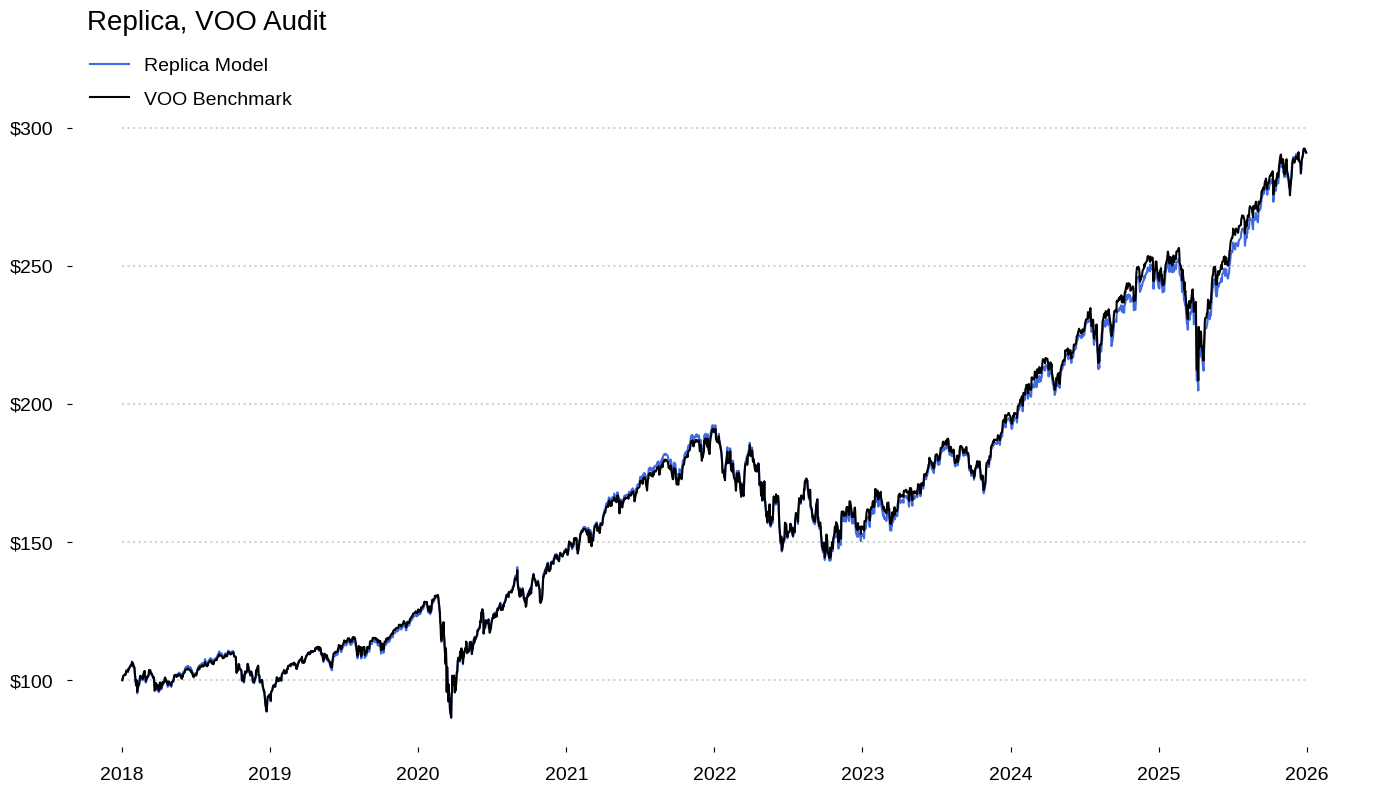

In [6]:
# Step 6.1: S&P 500 Audit & Visualization

# Audits output
# Benchmarks against VOO

# Output
model_path = os.path.join(DIRS["output"], "replica_final.csv")

if not os.path.exists(model_path):
    print(f"CRITICAL: Output file not found at {model_path}")
    print("Did you run the Step 5.1 (Clean slate) simulation?")
else:
    replica = pd.read_csv(model_path, index_col='date', parse_dates=True)

# Analysis window
    analysis_start = "2018-01-01"
    analysis_end   = "2025-12-31"
    replica_window = replica[(replica.index >= analysis_start) & (replica.index <= analysis_end)]

# Benchmark
    fetch_start = (replica_window.index[0] - pd.Timedelta(days=10)).strftime('%Y-%m-%d')
    fetch_end   = replica_window.index[-1].strftime('%Y-%m-%d')

    try:
# Added auto_adjust=False
        bench = yf.download(["VOO"], start=fetch_start, end=fetch_end, progress=False, auto_adjust=False)

        if isinstance(bench.columns, pd.MultiIndex):
            voo = bench.xs('VOO', axis=1, level=1)["Adj Close"]
        else:
            voo = bench["Adj Close"]

    except Exception as e:
        print(f"Error fetching VOO data: {e}")
        voo = pd.Series(dtype=float)

# Align data
    df = pd.DataFrame({
        'Model': replica_window['nav'],
        'VOO': voo,
        'Cash%': replica_window['cash_pct'],
        'Count': replica_window['constituents'] if 'constituents' in replica_window.columns else 0
    }).dropna()

# $100 basis
    df['Model_Norm'] = df['Model'] / df['Model'].iloc[0] * 100
    df['VOO_Norm'] = df['VOO'] / df['VOO'].iloc[0] * 100

# Audit table
    print("\n" + "━"*86)
    print(f"{'YEAR':<6} ┃ {'MODEL TR':>10} ┃ {'VOO TR':>10} ┃ {'ALPHA':>10} ┃ {'|ALPHA|':>10} ┃ {'AVG CASH':>10} ┃ {'TICKERS':>8}")
    print("━"*86)

    years = sorted(df.index.year.unique())
    abs_alphas = []

    for y in years:
        sub = df[df.index.year == y]
        if len(sub) < 10: continue

        ret_mod = (sub['Model'].iloc[-1] / sub['Model'].iloc[0]) - 1
        ret_bench = (sub['VOO'].iloc[-1] / sub['VOO'].iloc[0]) - 1

        annual_alpha = ret_mod - ret_bench
        abs_alpha = abs(annual_alpha)
        abs_alphas.append(abs_alpha)

        avg_cash = sub['Cash%'].mean() * 100
        avg_count = int(sub['Count'].mean())

        print(f"{y:<6} ┃ {ret_mod:>10.2%} ┃ {ret_bench:>10.2%} ┃ {annual_alpha:>10.2%} ┃ {abs_alpha:>10.2%} ┃ {avg_cash:>9.2f}% ┃ {int(avg_count):>8}")

    print("─" * 86)
    cum_mod = (df['Model'].iloc[-1] / df['Model'].iloc[0]) - 1
    cum_bench = (df['VOO'].iloc[-1] / df['VOO'].iloc[0]) - 1
    avg_abs_alpha = sum(abs_alphas) / len(abs_alphas) if abs_alphas else 0
    total_cash = df['Cash%'].mean() * 100
    total_count = int(df['Count'].mean())

    print(f"{'TOTAL':<6} ┃ {cum_mod:>10.2%} ┃ {cum_bench:>10.2%} ┃ {cum_mod-cum_bench:>10.2%} ┃ {avg_abs_alpha:>10.2%} ┃ {total_cash:>9.2f}% ┃ {int(total_count):>8}")
    print("━"*86)

    print("\n")

# Plot performance
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Liberation Sans', 'Arial', 'DejaVu Sans']

    fig, ax = plt.subplots(figsize=(14, 8), facecolor='white')
    ax.set_facecolor('white')

# Lines
    ax.plot(df.index, df['Model_Norm'], label='Replica Model', color='#4169E1', linewidth=1.5)
    ax.plot(df.index, df['VOO_Norm'], label='VOO Benchmark', color='black', linestyle='-', linewidth=1.5)

# Styling
    ax.grid(False)
    grid_color = '#D3D3D3'
    grid_start = pd.Timestamp('2018-01-01')
    grid_end = pd.Timestamp('2025-12-31')

# Y-levels
    y_levels = [100, 150, 200, 250, 300]
    for y in y_levels:
        ax.plot([grid_start, grid_end], [y, y], color=grid_color, linestyle=':', linewidth=1.5, zorder=0)

# Spines
    for s in ax.spines.values(): s.set_visible(False)

# Axis
    ax.tick_params(axis='both', which='major', labelsize=14, colors='black', pad=10)
    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
    ax.set_yticks(y_levels)
    ax.set_xlim(pd.Timestamp('2017-09-01'), pd.Timestamp('2026-06-30'))

# Spacing
    ax.text(x=pd.Timestamp('2017-10-08'), y=ax.get_ylim()[1] * 1.08, s="Replica, VOO Audit", fontsize=20, color='black')

# Legend
    ax.legend(loc='upper left', bbox_to_anchor=(0, 1.09), fontsize=14, frameon=False, ncol=1, labelspacing=0.8)

    plt.tight_layout()


# Export
    if not os.path.exists(DIRS["artifacts"]): os.makedirs(DIRS["artifacts"])
    save_path_png = os.path.join(DIRS["artifacts"], "Replica_VOO_Audit.png")
    plt.savefig(save_path_png, dpi=300, bbox_inches='tight', facecolor='white')

    plt.show()

Fetching OEF benchmark...

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
YEAR   ┃   MODEL TR ┃     OEF TR ┃      ALPHA ┃    |ALPHA| ┃   AVG CASH ┃  TICKERS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
2018   ┃     -5.65% ┃     -4.88% ┃     -0.77% ┃      0.77% ┃      0.50% ┃      100
2019   ┃     30.18% ┃     31.43% ┃     -1.25% ┃      1.25% ┃      0.50% ┃      100
2020   ┃     22.10% ┃     19.78% ┃      2.32% ┃      2.32% ┃      0.50% ┃      100
2021   ┃     32.13% ┃     30.85% ┃      1.28% ┃      1.28% ┃      0.50% ┃      100
2022   ┃    -24.58% ┃    -21.92% ┃     -2.66% ┃      2.66% ┃      0.50% ┃      100
2023   ┃     34.94% ┃     33.29% ┃      1.65% ┃      1.65% ┃      0.50% ┃      100
2024   ┃     30.28% ┃     31.60% ┃     -1.33% ┃      1.33% ┃      0.50% ┃      100
2025   ┃     24.95% ┃     20.87% ┃      4.08% ┃      4.08% ┃      0.50% ┃      100
────────────────────────────────────────────────────

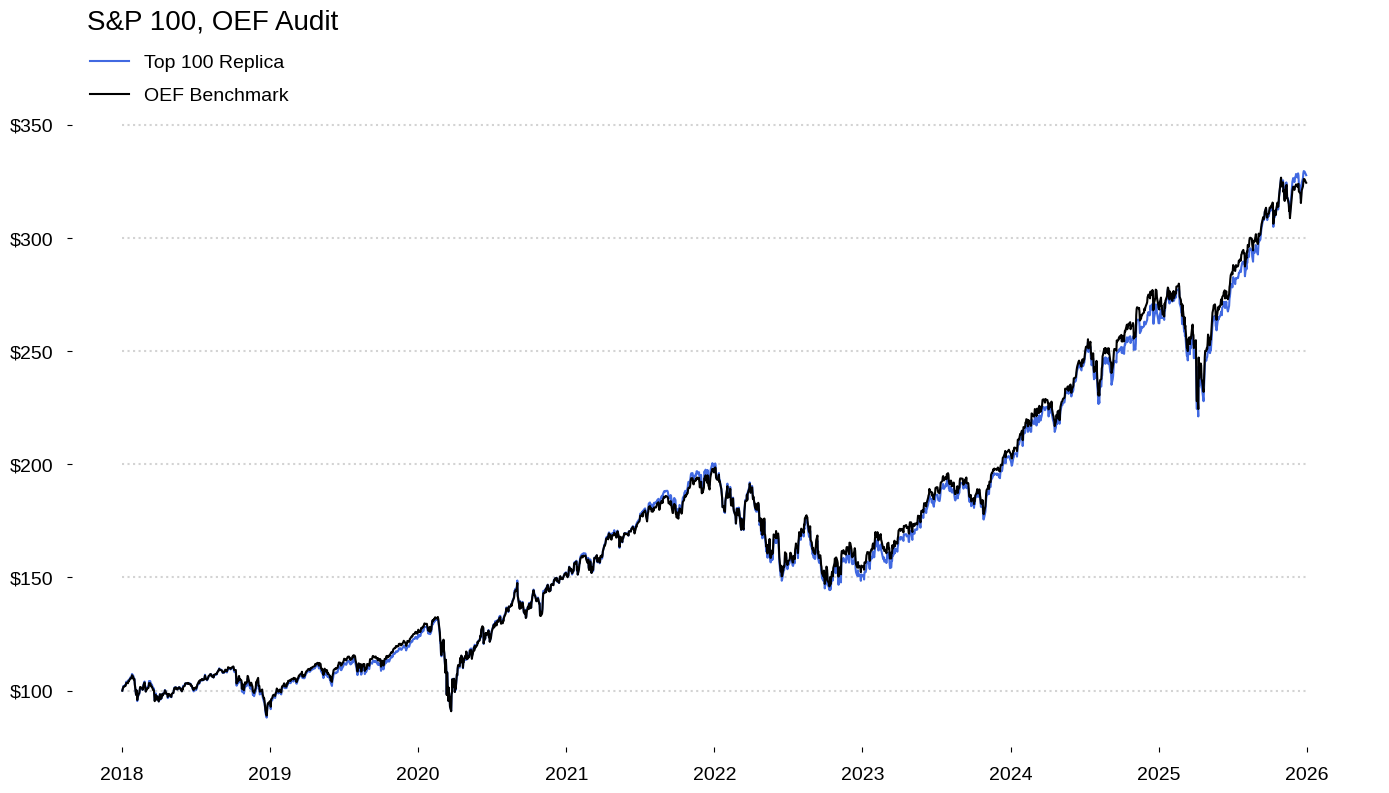

In [5]:
# Step 6.2: S&P 100 Audit & Visualization

import matplotlib.ticker as mtick
import logging
import warnings

# Suppress colab font warnings
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
warnings.filterwarnings("ignore", category=UserWarning)

model_path = os.path.join(DIRS["output"], "replica_sp100.csv")

if not os.path.exists(model_path):
    print("CRITICAL: Run step 5.2 first.")
else:
    replica = pd.read_csv(model_path, index_col='date', parse_dates=True)
    replica_window = replica[(replica.index >= "2018-01-01") & (replica.index <= "2025-12-31")]

# Benchmark
    print("Fetching OEF benchmark...")
    fetch_start = (replica_window.index[0] - pd.Timedelta(days=10)).strftime('%Y-%m-%d')
    fetch_end   = replica_window.index[-1].strftime('%Y-%m-%d')
    bench = yf.download(["OEF"], start=fetch_start, end=fetch_end, progress=False, auto_adjust=False)
    oef = bench.xs('OEF', axis=1, level=1)["Adj Close"] if isinstance(bench.columns, pd.MultiIndex) else bench["Adj Close"]

# Align data
    df = pd.DataFrame({'Model': replica_window['nav'], 'OEF': oef, 'Cash%': replica_window['cash_pct'], 'Count': replica_window['constituents']}).dropna()
    df['Model_Norm'] = df['Model'] / df['Model'].iloc[0] * 100
    df['OEF_Norm']   = df['OEF'] / df['OEF'].iloc[0] * 100

# Audit table
    print("\n" + "━"*86)
    print(f"{'YEAR':<6} ┃ {'MODEL TR':>10} ┃ {'OEF TR':>10} ┃ {'ALPHA':>10} ┃ {'|ALPHA|':>10} ┃ {'AVG CASH':>10} ┃ {'TICKERS':>8}")
    print("━"*86)

    years = sorted(df.index.year.unique())
    abs_alphas = []
    for y in years:
        sub = df[df.index.year == y]
        r_mod, r_bench = (sub['Model'].iloc[-1]/sub['Model'].iloc[0])-1, (sub['OEF'].iloc[-1]/sub['OEF'].iloc[0])-1
        abs_alphas.append(abs(r_mod-r_bench))
        print(f"{y:<6} ┃ {r_mod:>10.2%} ┃ {r_bench:>10.2%} ┃ {r_mod-r_bench:>10.2%} ┃ {abs(r_mod-r_bench):>10.2%} ┃ {sub['Cash%'].mean()*100:>9.2f}% ┃ {int(sub['Count'].mean()):>8}")

    print("─" * 86)
    cum_m, cum_o = (df['Model'].iloc[-1]/df['Model'].iloc[0])-1, (df['OEF'].iloc[-1]/df['OEF'].iloc[0])-1
    print(f"{'TOTAL':<6} ┃ {cum_m:>10.2%} ┃ {cum_o:>10.2%} ┃ {cum_m-cum_o:>10.2%} ┃ {sum(abs_alphas)/len(abs_alphas):>10.2%} ┃ {df['Cash%'].mean()*100:>9.2f}% ┃ {int(df['Count'].mean()):>8}")
    print("━"*86)

# Plot
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Liberation Sans', 'Arial', 'DejaVu Sans']

    fig, ax = plt.subplots(figsize=(14, 8), facecolor='white')
    ax.set_facecolor('white')

# Lines
    ax.plot(df.index, df['Model_Norm'], label='Top 100 Replica', color='#4169E1', linewidth=1.5)
    ax.plot(df.index, df['OEF_Norm'], label='OEF Benchmark', color='black', linestyle='-', linewidth=1.5)

# Styling
    ax.grid(False)
    grid_color = '#D3D3D3'
    for y in [100, 150, 200, 250, 300, 350]:
        ax.plot([df.index[0], df.index[-1]], [y, y], color=grid_color, linestyle=':', linewidth=1.5, zorder=0)

    for s in ax.spines.values(): s.set_visible(False)

# Axis
    ax.tick_params(axis='both', which='major', labelsize=14, colors='black', pad=10)
    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
    ax.set_xlim(pd.Timestamp('2017-09-01'), pd.Timestamp('2026-06-30'))

# Spacing
    ax.text(x=pd.Timestamp('2017-10-08'), y=ax.get_ylim()[1] * 1.08, s="S&P 100, OEF Audit", fontsize=20, color='black')

# Legend
    ax.legend(loc='upper left', bbox_to_anchor=(0, 1.09), fontsize=14, frameon=False, ncol=1, labelspacing=0.8)

    plt.tight_layout()

    print("\n")

# Export
    if not os.path.exists(DIRS["artifacts"]): os.makedirs(DIRS["artifacts"])
    save_path = os.path.join(DIRS["artifacts"], "S&P_100_OEF_Audit.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')

    plt.show()

In [ ]:
# Step 6.3: S&P 100 2025 Alpha Audit

# Filter to 2025
df_2025 = df[df.index.year == 2025].copy()

# Daily attribution

df_2025['daily_spread'] = df_2025['Model'].pct_change() - df_2025['OEF'].pct_change()

# Rebalance effect
rebal_2025 = [d for d in formal_rebal_dates if d.year == 2025]

print("━"*86)
print(f"{'2025 Audit: Top 10 Attribution Contributors':<86}")
print("━"*86)

# Weights from the March 2025 rebalance
m_rebal = rebal_2025[0]
if m_rebal in df_prices.index:
    weights_2025 = (df_mcap.loc[m_rebal] / df_mcap.loc[m_rebal].sum())
    top_weights = weights_2025.sort_values(ascending=False).head(100)

    print(f"{'TICKER':<10} ┃ {'WEIGHT':>10} ┃ {'YTD RETURN':>15} ┃ {'CONTRIBUTION TO ALPHA'}")
    print("─"*86)

    for ticker, weight in top_weights.items():
        ticker_ret = (df_prices.loc["2025-12-31", ticker] / df_prices.loc["2025-01-02", ticker]) - 1

        attrib = (weight * ticker_ret) * 100
        print(f"{ticker:<10} ┃ {weight:>10.2%} ┃ {ticker_ret:>15.2%} ┃ {attrib:>18.4f}%")

print("━"*56)

# Model's substantial alpha is due frictionless dividend reinvestment and position purchases. This is particular evident with Google in 2025.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
2025 Audit: Top 10 Attribution Contributors                                           
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TICKER     ┃     WEIGHT ┃      YTD RETURN ┃ CONTRIBUTION TO ALPHA
──────────────────────────────────────────────────────────────────────────────────────
AAPL       ┃      6.25% ┃          11.99% ┃             0.7500%
NVDA       ┃      5.52% ┃          34.88% ┃             1.9246%
MSFT       ┃      5.52% ┃          16.39% ┃             0.9041%
AMZN       ┃      3.99% ┃           4.81% ┃             0.1922%
GOOG       ┃      3.89% ┃          65.25% ┃             2.5353%
GOOGL      ┃      3.83% ┃          65.88% ┃             2.5248%
META       ┃      2.95% ┃          10.50% ┃             0.3099%
BRK-B      ┃      2.14% ┃          11.43% ┃             0.2442%
AVGO       ┃      1.75% ┃          50.54% ┃             0.8838%
TSLA      

Market Portfolio Returns




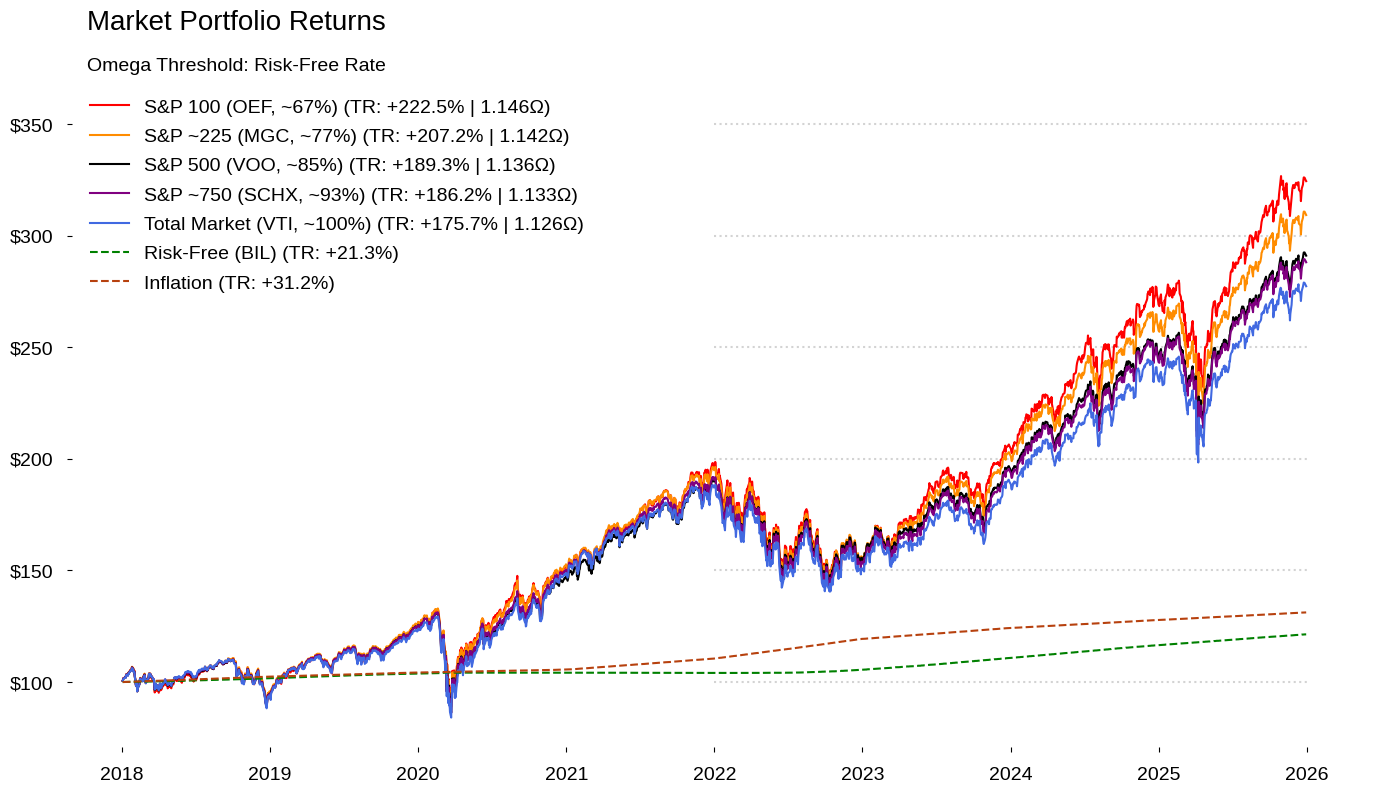

In [9]:
# Step 6.4 Market Portfolio Returns

print("Market Portfolio Returns")

# Download ETFs
tickers = ["OEF", "MGC", "VOO", "SCHX", "VTI", "BIL"]
df_down = yf.download(tickers, start="2018-01-01", end="2025-12-31", progress=False, auto_adjust=False)

df_clean = df_down['Adj Close'] if 'Adj Close' in df_down.columns else df_down['Close']
df_clean = df_clean.pct_change().dropna(how='all').dropna(axis=0)

# Colors
red, orange, blue = '#FF0000', '#FF8C00', '#4169E1'
black, purple = 'black', '#800080'
grid_color, rust = '#D3D3D3', '#b7410e'
THICKNESS = 1.5

# Define portfolios
portfolios = [
    {'name': 'S&P 100 (OEF, ~67%)', 'ret': df_clean['OEF'], 'color': red, 'style': '-'},
    {'name': 'S&P ~225 (MGC, ~77%)', 'ret': df_clean['MGC'], 'color': orange, 'style': '-'},
    {'name': 'S&P 500 (VOO, ~85%)', 'ret': df_clean['VOO'], 'color': black, 'style': '-'},
    {'name': 'S&P ~750 (SCHX, ~93%)', 'ret': df_clean['SCHX'], 'color': purple, 'style': '-'},
    {'name': 'Total Market (VTI, ~100%)', 'ret': df_clean['VTI'], 'color': blue, 'style': '-'},
    {'name': 'Risk-Free (BIL)', 'ret': df_clean['BIL'], 'color': 'green', 'style': '--'},
]

# Inflation benchmark
inf_map = {2018: 0.0244, 2019: 0.0181, 2020: 0.0123, 2021: 0.0470, 2022: 0.0800, 2023: 0.0412, 2024: 0.029, 2025: 0.0268}
inf_daily_list = [(1 + inf_map.get(d.year, 0.025))**(1/252) - 1 for d in df_clean.index]
ret_inf = pd.Series(inf_daily_list, index=df_clean.index)
portfolios.append({'name': 'Inflation', 'ret': ret_inf, 'color': rust, 'style': '--'})

# Labels
THRESHOLD = df_clean['BIL'].mean()
for p in portfolios:
    nav = (1 + p['ret']).cumprod() * 100
    total_ret_pct = (nav.iloc[-1] / nav.iloc[0] - 1) * 100

    # Omega
    excess = p['ret'] - THRESHOLD
    gains, losses = excess[excess > 0].sum(), -excess[excess < 0].sum()
    omega = gains / losses if losses != 0 else 0.0

    p['nav'] = nav
    suffix = f"(TR: +{total_ret_pct:.1f}% | {omega:.3f}Ω)" if p['name'] not in ['Inflation', 'Risk-Free (BIL)'] else f"(TR: +{total_ret_pct:.1f}%)"
    p['label'] = f"{p['name']} {suffix}"

# Plotting
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Liberation Sans', 'Arial', 'DejaVu Sans']

fig, ax = plt.subplots(figsize=(14, 8), facecolor='white')
ax.set_facecolor('white')

# Data Lines
for p in portfolios:
    ax.plot(p['nav'].index, p['nav'], label=p['label'], color=p['color'], linestyle=p['style'], linewidth=THICKNESS)

# Grid
ax.grid(False)
grid_start = pd.Timestamp('2022-01-01')
grid_end = pd.Timestamp('2025-12-31')
y_levels = [100, 150, 200, 250, 300, 350]

for y in y_levels:
    ax.plot([grid_start, grid_end], [y, y], color=grid_color, linestyle=':', linewidth=1.5, zorder=0)

# Axis
for s in ax.spines.values(): s.set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=14, colors='black', pad=10)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
ax.set_yticks(y_levels)


ax.set_xlim(pd.Timestamp('2017-09-01'), pd.Timestamp('2026-06-30'))

# Spacing
ax.text(x=pd.Timestamp('2017-10-08'), y=ax.get_ylim()[1] * 1.08, s="Market Portfolio Returns", fontsize=20, color='black')
ax.text(x=pd.Timestamp('2017-10-08'), y=ax.get_ylim()[1] * 1.03, s="Omega Threshold: Risk-Free Rate", fontsize=14, color='black')

# Legend
ax.legend(loc='upper left', bbox_to_anchor=(0, 1.02), fontsize=14, frameon=False, ncol=1, labelspacing=0.6)

plt.tight_layout()
print("\n")

# Export
if not os.path.exists(DIRS["artifacts"]): os.makedirs(DIRS["artifacts"])
save_path_png = os.path.join(DIRS["artifacts"], "Market_Portfolio_Returns.png")
plt.savefig(save_path_png, dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

S&P 500 Market Coverage




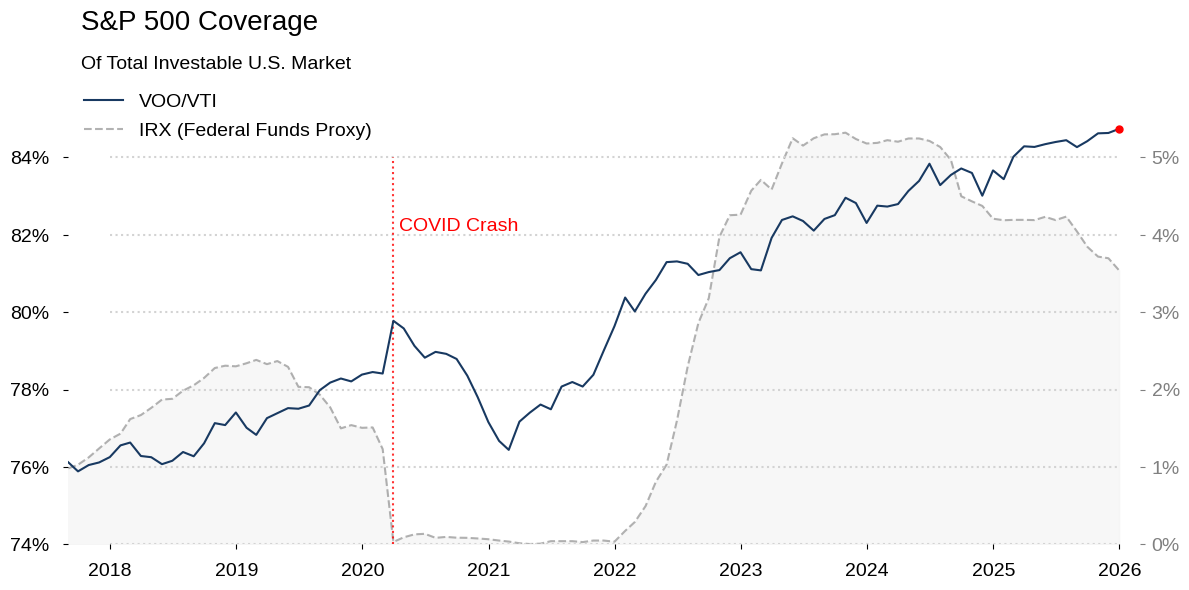

In [10]:
# Step 7.1 S&P 500 Market Coverage

TICKERS = ['VOO', 'VTI', '^IRX']

# S&P 500 to total market coverage ratio anchors are from https://siblisresearch.com/data/us-stock-market-value/. Model uses VOO/VTI for monthly directional changes.
siblis_start = 23938148.8 / 31774585.4
siblis_end = 58437956.6 / 68963152.8

# Colors
blue = '#183961'
red, grid_color, fed = '#FF0000', '#D3D3D3', '#808080'
Anchor_Size = 25
Covid = pd.Timestamp('2020-03-31')

# Configuration
ALIGN_X = pd.Timestamp('2017-10-08')
TITLE_Y = 0.873
SUBTITLE_Y = 0.863

# Legend
LEGEND_H_SHIFT = -0.001
LEGEND_V_SHIFT = 1.01

# Covid Label
COVID_LABEL_H_SHIFT = 190
COVID_LABEL_Y = 0.821

# Data
df = yf.download(TICKERS, start=START_DATE, end=END_DATE, progress=False, auto_adjust=False)
df_prices = df['Adj Close'].ffill() if 'Adj Close' in df.columns.levels[0] else df['Close'].ffill()
df_monthly = df_prices.resample('ME').last()

# Calibration
raw_ratio = df_monthly['VOO'] / df_monthly['VTI']
start_mult = siblis_start / raw_ratio.iloc[0]
end_mult = siblis_end / raw_ratio.iloc[-1]
monthly_multipliers = np.linspace(start_mult, end_mult, len(raw_ratio))
coverage_series = raw_ratio * monthly_multipliers
fed_rate = df_monthly['^IRX'] / 100

# Plotting
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Liberation Sans', 'Arial', 'DejaVu Sans']


fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')
ax.set_facecolor('white')

# Fed rate
ax2 = ax.twinx()
ax.set_zorder(ax2.get_zorder() + 1)
ax.patch.set_visible(False)
ax2.fill_between(fed_rate.index, 0, fed_rate, color='#F2F2F2', alpha=0.6, zorder=0)
ax2.plot(fed_rate.index, fed_rate, label='IRX (Federal Funds Proxy)',
         color=fed, linestyle='--', linewidth=1.5, alpha=0.6)


# Fed ticks
ax2.set_ylim(0, 0.06)
ax2.set_yticks([0, 0.01, 0.02, 0.03, 0.04, 0.05])
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax2.tick_params(axis='y', colors=fed, labelsize=14, pad=5)

# Coverage line
ax.plot(coverage_series.index, coverage_series, label='VOO/VTI',
        color=blue, linewidth=1.5, zorder=5)

# Scatter line
ax.scatter([coverage_series.index[0], coverage_series.index[-1]],
           [siblis_start, siblis_end],
           color=red, s=Anchor_Size, zorder=10)

# Covid line
ax.vlines(x=Covid, ymin=0.74, ymax=0.84, color=red, linestyle=':', linewidth=1.5, alpha=0.8, zorder=4)

# Covid shift
ax.text(x=Covid + pd.Timedelta(days=COVID_LABEL_H_SHIFT),
        y=COVID_LABEL_Y,
        s="COVID Crash",
        color=red,
        fontsize=14,
        ha='center',
        fontweight='normal')

# Grid
ax.grid(False)
grid_start, grid_end = pd.Timestamp('2018-01-01'), pd.Timestamp('2025-12-31')
y_levels = [0.74, 0.76, 0.78, 0.80, 0.82, 0.84]

for y in y_levels:
    ax.plot([grid_start, grid_end], [y, y], color=grid_color, linestyle=':', linewidth=1.5, zorder=0)

# Ticks
for s in list(ax.spines.values()) + list(ax2.spines.values()): s.set_visible(False)

ax.tick_params(axis='both', which='major', labelsize=14, colors='black', pad=10)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.set_yticks(y_levels)
ax.set_ylim(0.74, 0.86)

# X-Axis
ax.set_xlim(pd.Timestamp('2017-09-01'), pd.Timestamp('2026-03-01'))

# Header
ax.text(x=ALIGN_X, y=TITLE_Y, s="S&P 500 Coverage", fontsize=20, fontweight='normal', ha='left')
ax.text(x=ALIGN_X, y=SUBTITLE_Y, s="Of Total Investable U.S. Market", fontsize=14, ha='left')

lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax.legend(lines + lines2, labels + labels2, loc='upper left',
          bbox_to_anchor=(LEGEND_H_SHIFT, LEGEND_V_SHIFT), fontsize=14, frameon=False, labelspacing=0.6)

plt.tight_layout()

# Export
if 'DIRS' in locals() and os.path.exists(DIRS.get("artifacts", "")):
    save_path_png = os.path.join(DIRS["artifacts"], "S&P_500_Market_Coverage.png")
    plt.savefig(save_path_png, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"S&P 500 Market Coverage")

    print("\n")

plt.show()

Efficiency vs. Performance Profile



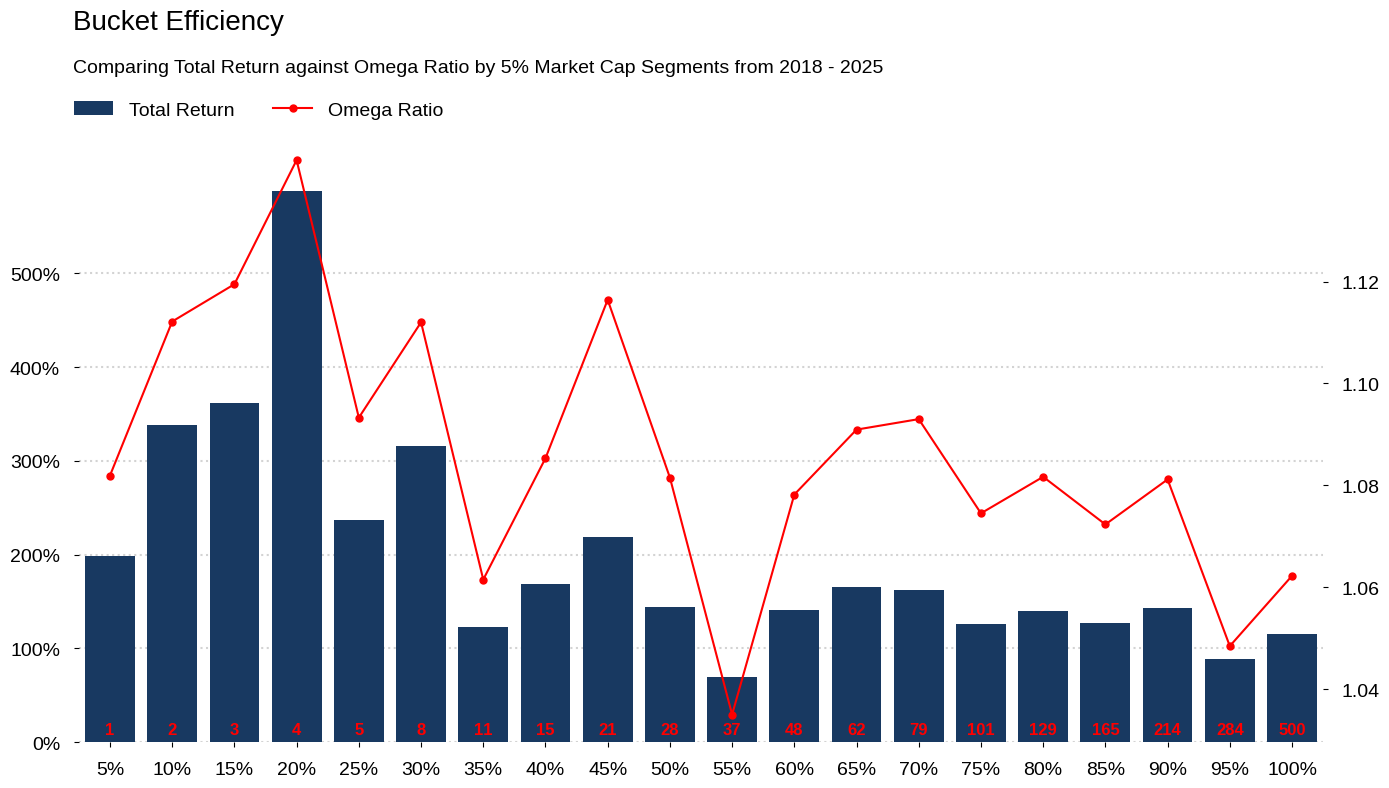

In [12]:
# Step 7.2 Bucket Efficiency

print("Efficiency vs. Performance Profile")
print("")

# Matrices
mcaps = pd.read_parquet(os.path.join(DIRS["output"], "master_mcaps.parquet")).loc["2018-01-01":"2025-12-31"]
prices = pd.read_parquet(os.path.join(DIRS["output"], "master_prices_adj.parquet")).loc["2018-01-01":"2025-12-31"]

# Warnings
returns = prices.pct_change(fill_method=None).fillna(0)
lagged_mcaps = mcaps.shift(1)

# Omega (5% annualized)
THRESHOLD = 0.05 / 252

# Buckets
def calc_20_buckets(m_row, r_row):
    if m_row.sum() == 0: return [0.0] * 20, [0] * 20
    sorted_idx = m_row.sort_values(ascending=False).index
    m_sorted, r_sorted = m_row[sorted_idx], r_row[sorted_idx]
    cum_w = m_sorted.cumsum() / m_sorted.sum()

    rets = []
    counts = []
    for i in range(20):
        mask = (cum_w > i*0.05) & (cum_w <= (i+1)*0.05)
        if i == 0: mask.iloc[0] = True
        b_m, b_r = m_sorted[mask], r_sorted[mask]
        rets.append(((b_m / b_m.sum()) * b_r).sum() if b_m.sum() > 0 else 0.0)
        counts.append(mask.sum())
    return rets, counts

results = [calc_20_buckets(lagged_mcaps.loc[d], returns.loc[d]) for d in lagged_mcaps.index]
bucket_rets = [res[0] for res in results]
bucket_counts = [res[1] for res in results]

df_b = pd.DataFrame(bucket_rets, index=lagged_mcaps.index, columns=[f'{i+1}' for i in range(20)])
df_c = pd.DataFrame(bucket_counts, index=lagged_mcaps.index, columns=[f'{i+1}' for i in range(20)])

# Average daily counts
avg_daily_per_bucket = df_c.mean()
scaled_counts = (avg_daily_per_bucket / avg_daily_per_bucket.sum()) * 500
cumulative_scaled = scaled_counts.cumsum()

stats = []
for i, col in enumerate(df_b.columns):
    r = df_b[col]
    total_ret = ((1 + r).prod() - 1) * 100
    gains = r[r > THRESHOLD] - THRESHOLD
    losses = THRESHOLD - r[r <= THRESHOLD]
    omega = gains.sum() / losses.sum() if losses.sum() != 0 else 0

    stats.append({
        'Bucket': col,
        'Return': total_ret,
        'Omega': omega,
        'CumStocks': round(cumulative_scaled.iloc[i])
    })

df_stats = pd.DataFrame(stats)

# Colors
blue, red_hex = '#183961', '#FF0000'
black = 'black'
grid_color = '#D3D3D3'
THICKNESS = 1.5

# Plotting
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Liberation Sans', 'Arial', 'DejaVu Sans']

fig, ax1 = plt.subplots(figsize=(14, 8), facecolor='white')
ax1.set_facecolor('white')
ax2 = ax1.twinx()

# Data lines
bars = ax1.bar(df_stats['Bucket'], df_stats['Return'], color=blue, alpha=1.0, zorder=3, label='Total Return')
line, = ax2.plot(df_stats['Bucket'], df_stats['Omega'], color=red_hex, marker='o', linewidth=THICKNESS, markersize=5, zorder=4, label='Omega Ratio')

# Numbers of stocks
for i, row in df_stats.iterrows():
    ax1.text(i, 0.02, f"{int(row['CumStocks'])}",
             color=red_hex,
             ha='center',
             va='center',
             fontsize=12,
             fontweight='bold',
             zorder=5,
             transform=ax1.get_xaxis_transform())

# Alignment
ax1.set_ylim(0, 650)
ax2_bottom = ax2.get_ylim()[0]
ax2_top = ax2_bottom + (1.14 - ax2_bottom) * (650 / 600)
ax2.set_ylim(ax2_bottom, ax2_top)

# Grid
ax1.grid(False)
ax2.grid(False)

fig.canvas.draw()
y_levels = ax1.get_yticks()
for y in y_levels:
    if np.isclose(y, 600, atol=0.1): continue
    ax1.plot([-0.5, 19.5], [y, y], color=grid_color, linestyle=':', linewidth=1.5, zorder=0)

# Axis
for s in ax1.spines.values(): s.set_visible(False)
for s in ax2.spines.values(): s.set_visible(False)

ax1.tick_params(axis='both', which='major', labelsize=14, colors='black', pad=10)
ax2.tick_params(axis='y', which='major', labelsize=14, colors='black', pad=10)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

# Axes
for tick in ax1.yaxis.get_major_ticks():
    if np.isclose(tick.get_loc(), 600, atol=0.1):
        tick.label1.set_visible(False)
        tick.tick1line.set_visible(False)

for tick in ax2.yaxis.get_major_ticks():
    if np.isclose(tick.get_loc(), 1.14, atol=0.001):
        tick.label2.set_visible(False)
        tick.tick2line.set_visible(False)

# Labels
ax1.set_xlim(-0.5, 19.5)
ax1.set_xticks(range(20))
ax1.set_xticklabels([f"{(i+1)*5}%" for i in range(20)])

# Titles
ax1.text(x=-0.005, y=1.17, s="Bucket Efficiency", fontsize=20, color='black', transform=ax1.transAxes, clip_on=False)
ax1.text(x=-0.005, y=1.10, s="Comparing Total Return against Omega Ratio by 5% Market Cap Segments from 2018 - 2025", fontsize=14, color='black', transform=ax1.transAxes, clip_on=False)

# Legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
red_proxy = Line2D([0], [0], color='white', marker=None)
all_lines = lines + lines2 + [red_proxy]
all_labels = labels + labels2 + [""]
leg = ax1.legend(all_lines, all_labels, loc='lower left', bbox_to_anchor=(-0.01, 1.01), fontsize=14, frameon=False, ncol=3, labelspacing=0.6, borderaxespad=0)
plt.setp(leg.get_texts()[-1], color=red_hex)

plt.tight_layout()

# Export
if not os.path.exists(DIRS["artifacts"]): os.makedirs(DIRS["artifacts"])
save_path_png = os.path.join(DIRS["artifacts"], "Bucket_Efficiency.png")
plt.savefig(save_path_png, dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

Market Portfolio Returns (N-Stock Pegs)

Calculating daily returns for S&P 1...
Calculating daily returns for S&P 5...
Calculating daily returns for S&P 10...
Calculating daily returns for S&P 50...
Calculating daily returns for S&P 500...




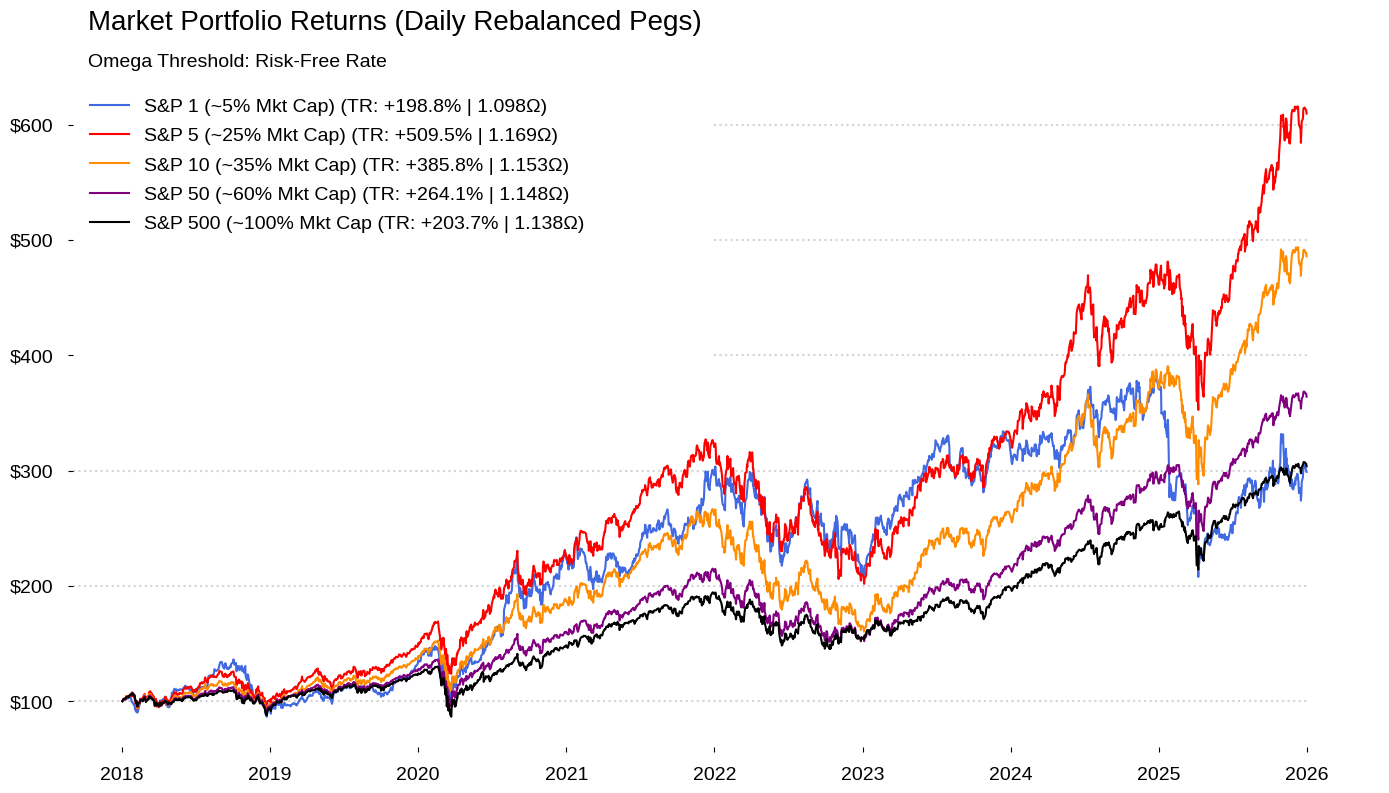

In [28]:
# Step 7.3 Market Portfolio Returns (N-Stock Pegs)

print("Market Portfolio Returns (N-Stock Pegs)")
print("")

# 1. Load matrices
mcaps = pd.read_parquet(os.path.join(DIRS["output"], "master_mcaps.parquet")).loc["2018-01-01":"2025-12-31"]
prices = pd.read_parquet(os.path.join(DIRS["output"], "master_prices_adj.parquet")).loc["2018-01-01":"2025-12-31"]

# Warnings
returns = prices.pct_change(fill_method=None).fillna(0)
lagged_mcaps = mcaps.shift(1).fillna(0)

# Rebalancing Engine
def calc_top_n_daily_returns(n):
    daily_rets = []

    # Iterate
    for d in lagged_mcaps.index:
        m_row = lagged_mcaps.loc[d]
        if m_row.sum() == 0:
            daily_rets.append(0.0)
            continue

        # Peg
        top_n_idx = m_row.nlargest(n).index

        b_m = m_row[top_n_idx]
        b_r = returns.loc[d, top_n_idx]

        # Weighted return
        if b_m.sum() > 0:
            daily_rets.append(((b_m / b_m.sum()) * b_r).sum())
        else:
            daily_rets.append(0.0)

    return pd.Series(daily_rets, index=lagged_mcaps.index)

print("Calculating daily returns for S&P 1...")
sp1_ret = calc_top_n_daily_returns(1)
print("Calculating daily returns for S&P 5...")
sp5_ret = calc_top_n_daily_returns(5)
print("Calculating daily returns for S&P 10...")
sp10_ret = calc_top_n_daily_returns(10)
print("Calculating daily returns for S&P 50...")
sp50_ret = calc_top_n_daily_returns(50)
print("Calculating daily returns for S&P 500...")
sp500_ret = calc_top_n_daily_returns(500)

# BIL
tickers = ["BIL"]
df_down = yf.download(tickers, start="2018-01-01", end="2025-12-31", progress=False, auto_adjust=False)

df_clean = pd.DataFrame()
df_clean['BIL'] = df_down['Adj Close']['BIL'] if 'Adj Close' in df_down.columns else df_down['Close']['BIL']
df_clean = df_clean.pct_change().dropna(how='all').dropna(axis=0)

# Colors
blue, red, orange, purple, black = '#4169E1', '#FF0000', '#FF8C00', '#800080', 'black'
grid_color = '#D3D3D3'
THICKNESS = 1.5

# Define portfolios
portfolios = [
    {'name': 'S&P 1 (~5% Mkt Cap)', 'ret': sp1_ret, 'color': blue, 'style': '-'},
    {'name': 'S&P 5 (~25% Mkt Cap)', 'ret': sp5_ret, 'color': red, 'style': '-'},
    {'name': 'S&P 10 (~35% Mkt Cap)', 'ret': sp10_ret, 'color': orange, 'style': '-'},
    {'name': 'S&P 50 (~60% Mkt Cap)', 'ret': sp50_ret, 'color': purple, 'style': '-'},
    {'name': 'S&P 500 (~100% Mkt Cap', 'ret': sp500_ret, 'color': black, 'style': '-'},
]

# Labels
THRESHOLD = df_clean['BIL'].mean()
for p in portfolios:
    nav = (1 + p['ret']).cumprod() * 100
    total_ret_pct = (nav.iloc[-1] / nav.iloc[0] - 1) * 100

    # Omega
    excess = p['ret'] - THRESHOLD
    gains, losses = excess[excess > 0].sum(), -excess[excess < 0].sum()
    omega = gains / losses if losses != 0 else 0.0

    p['nav'] = nav
    suffix = f"(TR: +{total_ret_pct:.1f}% | {omega:.3f}Ω)"
    p['label'] = f"{p['name']} {suffix}"

# Plotting
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Liberation Sans', 'Arial', 'DejaVu Sans']

fig, ax = plt.subplots(figsize=(14, 8), facecolor='white')
ax.set_facecolor('white')

# Lines
for p in portfolios:
    ax.plot(p['nav'].index, p['nav'], label=p['label'], color=p['color'], linestyle=p['style'], linewidth=THICKNESS)

# Grid
ax.grid(False)
grid_start_full = pd.Timestamp('2017-09-01')
grid_end_full = pd.Timestamp('2025-12-31')
grid_start_half = pd.Timestamp('2022-01-01')
grid_end_half = pd.Timestamp('2025-12-31')

# Ticks
y_levels = [100, 200, 300, 400, 500, 600]

# Gridlines
for y in y_levels:
    if y <= 300:
        ax.plot([grid_start_full, grid_end_full], [y, y], color=grid_color, linestyle=':', linewidth=1.5, zorder=0)
    else:
        ax.plot([grid_start_half, grid_end_half], [y, y], color=grid_color, linestyle=':', linewidth=1.5, zorder=0)

# Axis
for s in ax.spines.values(): s.set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=14, colors='black', pad=10)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
ax.set_yticks(y_levels)

# Scaling axis
current_ylim = ax.get_ylim()
ax.set_ylim(current_ylim[0], 650)
ax.set_xlim(pd.Timestamp('2017-09-01'), pd.Timestamp('2026-06-30'))

# Titles
ax.text(x=pd.Timestamp('2017-10-08'), y=ax.get_ylim()[1] * 1.05, s="Market Portfolio Returns (Daily Rebalanced Pegs)", fontsize=20, color='black', clip_on=False)
ax.text(x=pd.Timestamp('2017-10-08'), y=ax.get_ylim()[1] * 1.0, s="Omega Threshold: Risk-Free Rate", fontsize=14, color='black', clip_on=False)

# Legend
ax.legend(loc='upper left', bbox_to_anchor=(0, 0.98), fontsize=14, frameon=False, ncol=1, labelspacing=0.6)

plt.tight_layout()
print("\n")

# Export
if not os.path.exists(DIRS["artifacts"]): os.makedirs(DIRS["artifacts"])
save_path_png = os.path.join(DIRS["artifacts"], "Market_Portfolio_Daily_Rebalanced_Pegs.png")
plt.savefig(save_path_png, dpi=300, bbox_inches='tight', facecolor='white')

plt.show()